## Downscaling and moving windows
- Downscaling building volume and tree volume rasters to 30m to have same-level scale with LST images 
- computing moving windows and study the correlations with LST depending on the size of the window.

### Libraries and general paths

In [ ]:
!pip install rasterio

In [1]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
import numpy as np
from rasterio.windows import Window
from rasterio.warp import reproject, Resampling
from scipy.ndimage import uniform_filter
import os
from scipy.ndimage import convolve

In [2]:
# user-defined paths
base_dir = '../../../datos-notebooks/3.global-data-cba/'

In [9]:
# derived paths

# LST
lst_cropped_path = os.path.join(base_dir, 'LST/LST_cropped_celsius.tif') # values out of bound are 0
lst_clipped_path = os.path.join(base_dir, 'LST/LST_clipped_celsius.tif') #values out of bound are nan

#inputs
rasters_base = os.path.join(base_dir, 'objects-height/rasterized-1m/')
building_raster_path = os.path.join(rasters_base, 'buildings_height_1m.tif')
trees_raster_path = os.path.join(rasters_base, 'trees_height_1m.tif')
build_footprint = os.path.join(rasters_base, 'buildings_footprint_1m.tif')

# Downscaled rasters at 30m resolution
downscaled_folder = os.path.join(base_dir, 'objects-height/downscaled/')
os.makedirs(downscaled_folder, exist_ok=True)
build_footprint_30m = os.path.join(downscaled_folder, 'buildings_footprint_30m.tif')
build_volume_30m = os.path.join(downscaled_folder, 'buildings_volume_30m.tif')
tree_volume_30m = os.path.join(downscaled_folder, 'trees_volume_30m.tif')
tree_height_30m = os.path.join(downscaled_folder, 'trees_height_30m.tif')
build_height_30m = os.path.join(downscaled_folder, 'buildings_height_30m.tif')
    
# Moving windows 
mw_folder = os.path.join(base_dir, 'objects-height/moving-windows/')
os.makedirs(mw_folder, exist_ok=True)
mw_building_area = os.path.join(mw_folder, 'building-area/')
os.makedirs(mw_building_area, exist_ok=True)
mw_building_volume = os.path.join(mw_folder, 'building-volume/')
os.makedirs(mw_building_volume, exist_ok=True)
mw_tree_volume = os.path.join(mw_folder, 'tree-volume/')
os.makedirs(mw_tree_volume, exist_ok=True)
mw_building_height = os.path.join(mw_folder, 'building-height/')
os.makedirs(mw_building_height, exist_ok=True)
mw_tree_height = os.path.join(mw_folder, 'tree-height/')
os.makedirs(mw_tree_height, exist_ok=True)

In [10]:
# Load LST
with rasterio.open(lst_clipped_path) as lst:
    lst_crs = lst.crs
    lst_clip = lst.read(1)          
    lst_transform = lst.transform  

### Downscaling

#### Building Height

In [ ]:
with rasterio.open(building_raster_path) as src:
    window = rasterio.windows.Window(col_off=15000, row_off=7000, width=3000, height=3000)  # adjust as needed
    data = src.read(1, window=window)

plt.figure(figsize=(8,8))
plt.imshow(data, cmap='viridis')
plt.colorbar(label='Height')
plt.show()

In [ ]:

# Downscale: mean height, ignoring zero values -- 32 minutes

# Open LST (target grid) 
with rasterio.open(lst_cropped_path) as lst:
    lst_transform = lst.transform
    lst_crs = lst.crs
    out_shape = (lst.height, lst.width)
    out_profile = lst.profile.copy()

# Open source raster
src = rasterio.open(building_raster_path)

# Accumulators
sum_arr = np.zeros(out_shape, dtype=np.float32)
count_arr = np.zeros(out_shape, dtype=np.uint16)

# Process by blocks
for _, window in src.block_windows(1):

    data = src.read(1, window=window).astype(np.float32)

    # Ignore zeros
    valid = data > 0
    if not valid.any():
        continue

    data[~valid] = 0

    # Temporary arrays
    tmp_sum = np.zeros(out_shape, dtype=np.float32)
    tmp_count = np.zeros(out_shape, dtype=np.uint16)

    # Reproject values (sum)
    reproject(
        source=data,
        destination=tmp_sum,
        src_transform=src.window_transform(window),
        src_crs=src.crs,
        dst_transform=lst_transform,
        dst_crs=lst_crs,
        resampling=Resampling.sum,
        src_nodata=0,
        dst_nodata=0
    )

    # Reproject counts (1 where valid)
    reproject(
        source=valid.astype(np.uint8),
        destination=tmp_count,
        src_transform=src.window_transform(window),
        src_crs=src.crs,
        dst_transform=lst_transform,
        dst_crs=lst_crs,
        resampling=Resampling.sum,
        src_nodata=0,
        dst_nodata=0
    )

    sum_arr += tmp_sum
    count_arr += tmp_count

src.close()

# Final average (ignoring zeros)
avg = np.zeros(out_shape, dtype=np.float32)
mask = count_arr > 0
avg[mask] = sum_arr[mask] / count_arr[mask]

# Save output
out_profile.update(
    dtype=rasterio.float32,
    count=1,
    compress="lzw",
    nodata=0
)

with rasterio.open(build_height_30m, "w", **out_profile) as dst:
    dst.write(avg, 1)

print("Saved:", build_height_30m)



In [ ]:
with rasterio.open(build_height_30m) as src:
    build_footprint_data = src.read(1)

plt.figure(figsize=(10,8))
plt.imshow(build_footprint_data, cmap='turbo', vmin=0, vmax=30)
plt.colorbar(label='Built height (m)')
plt.title('Building (mean) height at 30m resolution')
plt.show()

#### Building area

In [ ]:
with rasterio.open(building_raster_path) as src:
    data = src.read(1)
    profile = src.profile

# Create binary raster: 1 = built area, 0 = no building
footprint = np.where(np.isnan(data) | (data <= 0), 0, 1).astype(np.uint8)

# Save raster
profile.update(dtype=rasterio.uint8, count=1, compress='lzw')

with rasterio.open(build_footprint, 'w', **profile) as dst:
    dst.write(footprint, 1)

print("Saved:", build_footprint)


In [ ]:
with rasterio.open(build_footprint) as src:
    window = rasterio.windows.Window(col_off=15000, row_off=7000, width=8000, height=8000)  # adjust as needed
    data = src.read(1, window=window)

plt.figure(figsize=(8,8))
plt.imshow(data, cmap='viridis')
plt.colorbar(label='Footprint')
plt.show()

In [ ]:
# 11 minutes

# Open LST for spatial reference
with rasterio.open(lst_cropped_path) as src_lst:
    lst_profile = src_lst.profile
    lst_transform = src_lst.transform
    lst_crs = src_lst.crs
    lst_shape = (src_lst.height, src_lst.width)
    lst_res = src_lst.res[0]  # pixel size (e.g. 30 m)

# Read building footprint raster
with rasterio.open(build_footprint) as src:
    footprint_data = src.read(1).astype(float)
    footprint_transform = src.transform
    footprint_crs = src.crs
    footprint_res = src.res[0]  # pixel size (e.g. 0.5 m)

# Reproject with sum (to count built subpixels per LST pixel)
resampled = np.empty(lst_shape, dtype=np.float32)

reproject(
    source=footprint_data,
    destination=resampled,
    src_transform=footprint_transform,
    src_crs=footprint_crs,
    dst_transform=lst_transform,
    dst_crs=lst_crs,
    resampling=Resampling.sum
)

# Convert to built fraction
scale_factor = (lst_res / footprint_res) ** 2  # number of 0.5m pixels per LST pixel
fraction_built = resampled / scale_factor      # fraction between 0 and 1

# Save result
out_profile = lst_profile.copy()
out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')

with rasterio.open(build_footprint_30m, 'w', **out_profile) as dst:
    dst.write(fraction_built, 1)

print("Saved:", build_footprint_30m) 

In [ ]:
with rasterio.open(build_footprint_30m) as src:
    build_footprint_data = src.read(1)

plt.figure(figsize=(8,6))
plt.imshow(build_footprint_data, cmap='turbo')
plt.colorbar(label='Built fraction')
plt.title('Built fraction at 30m resolution')
plt.show()

#### Building volume

In [ ]:
# For each 30m pixel, it sums building volumes computed using 1m raster: heights multiplied by pixel area.

# Load LST to get shape, transform, CRS, and pixel size
with rasterio.open(lst_cropped_path) as src_lst:
    lst_crs = src_lst.crs
    lst_transform = src_lst.transform
    lst_height = src_lst.height
    lst_width = src_lst.width
    lst_res_x = src_lst.res[0]  # Size of LST pixel in X
    lst_res_y = src_lst.res[1]  # Size of LST pixel in Y

# Open 1m building raster
with rasterio.open(building_raster_path) as src_build:
    build_data = src_build.read(1)
    build_res = src_build.res[0]  
    build_transform = src_build.transform

# Aggregation factor
factor_x = int(lst_res_x / build_res)
factor_y = int(lst_res_y / build_res)
    
# Initialize volume raster
volume_raster = np.zeros((lst_height, lst_width), dtype=np.float32)
pixel_area = build_res * build_res  # area of each 0.5 m pixel

# Downscaling by summing volumes
for i in range(lst_height):
    for j in range(lst_width):
        # calculate window of pixels in build_data that fall within the LST pixel
        row_start = i * factor_y
        row_end = min((i+1) * factor_y, build_data.shape[0])
        col_start = j * factor_x
        col_end = min((j+1) * factor_x, build_data.shape[1])

        # extract block and sum volumes
        block = build_data[row_start:row_end, col_start:col_end]
        block = np.nan_to_num(block)  # convert NaN to 0
        volume_raster[i, j] = np.sum(block * pixel_area)

# Save raster
with rasterio.open(
    build_volume_30m,
    'w',
    driver='GTiff',
    height=lst_height,
    width=lst_width,
    count=1,
    dtype=volume_raster.dtype,
    crs=lst_crs,
    transform=lst_transform
) as dst:
    dst.write(volume_raster, 1)


In [ ]:
plt.figure(figsize=(8,6))
plt.imshow(volume_raster, cmap='turbo')  # values up to 50.000 but vmax set for better visualization
plt.colorbar(label='Built volume (m³)')
plt.title('Built volume')
plt.show()

#### Trees volume

In [ ]:
# Load LST to get shape, transform, CRS, and pixel size
with rasterio.open(lst_cropped_path) as src_lst:
    lst_crs = src_lst.crs
    lst_transform = src_lst.transform
    lst_height = src_lst.height
    lst_width = src_lst.width
    lst_res_x = src_lst.res[0]  # tamaño de pixel LST en X
    lst_res_y = src_lst.res[1]  # tamaño de pixel LST en Y

# Load high-res tree raster
with rasterio.open(trees_raster_path) as src_tree:
    build_data = src_tree.read(1)
    build_res = src_tree.res[0]  # asumimos cuadrado 0.5m
    build_transform = src_tree.transform

#Aggregation factor
factor_x = int(lst_res_x / build_res)
factor_y = int(lst_res_y / build_res)

# Inicialyze volume raster
volume_raster = np.zeros((lst_height, lst_width), dtype=np.float32)
pixel_area = build_res * build_res  # área de cada pixel 0.5 m

# Downscaling by summing volumes
for i in range(lst_height):
    for j in range(lst_width):
 
        row_start = i * factor_y
        row_end = min((i+1) * factor_y, build_data.shape[0])
        col_start = j * factor_x
        col_end = min((j+1) * factor_x, build_data.shape[1])
        
        # extract block and sum volumes
        block = build_data[row_start:row_end, col_start:col_end]
        block = np.nan_to_num(block)  # convertir NaN a 0
        volume_raster[i, j] = np.sum(block * pixel_area)

# Save raster
with rasterio.open(
    tree_volume_30m,
    'w',
    driver='GTiff',
    height=lst_height,
    width=lst_width,
    count=1,
    dtype=volume_raster.dtype,
    crs=lst_crs,
    transform=lst_transform
) as dst:
    dst.write(volume_raster, 1)

In [ ]:
plt.figure(figsize=(8,6))
plt.imshow(volume_raster, cmap='turbo')  
plt.colorbar(label='vegetation volume (m³)')
plt.title('vegetation volume')
plt.show()

#### trees heught

In [11]:
# Open LST for spatial reference
with rasterio.open(lst_cropped_path) as src_lst:
    lst_profile = src_lst.profile
    lst_transform = src_lst.transform
    lst_crs = src_lst.crs
    lst_shape = (src_lst.height, src_lst.width)

# Read tree height raster
with rasterio.open(trees_raster_path) as src:
    tree_data = src.read(1).astype(float)
    tree_transform = src.transform
    tree_crs = src.crs

# Mask non-tree pixels (ignore them in average)
tree_data_masked = np.where(tree_data > 0, tree_data, np.nan)

# Prepare output array
resampled = np.empty(lst_shape, dtype=np.float32)

# Reproject using spatial average (ignores NaNs)
reproject(
    source=tree_data_masked,
    destination=resampled,
    src_transform=tree_transform,
    src_crs=tree_crs,
    dst_transform=lst_transform,
    dst_crs=lst_crs,
    resampling=Resampling.average,
    src_nodata=np.nan,
    dst_nodata=np.nan
)

# Replace remaining NaN with 0
resampled = np.nan_to_num(resampled, nan=0.0)

# Save result
out_profile = lst_profile.copy()
out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')

with rasterio.open(tree_height_30m, 'w', **out_profile) as dst:
    dst.write(resampled, 1)

print("Saved:", tree_height_30m)

Saved: ../../../datos-notebooks/3.global-data-cba/objects-height/downscaled/trees_height_30m.tif


#### plotting all

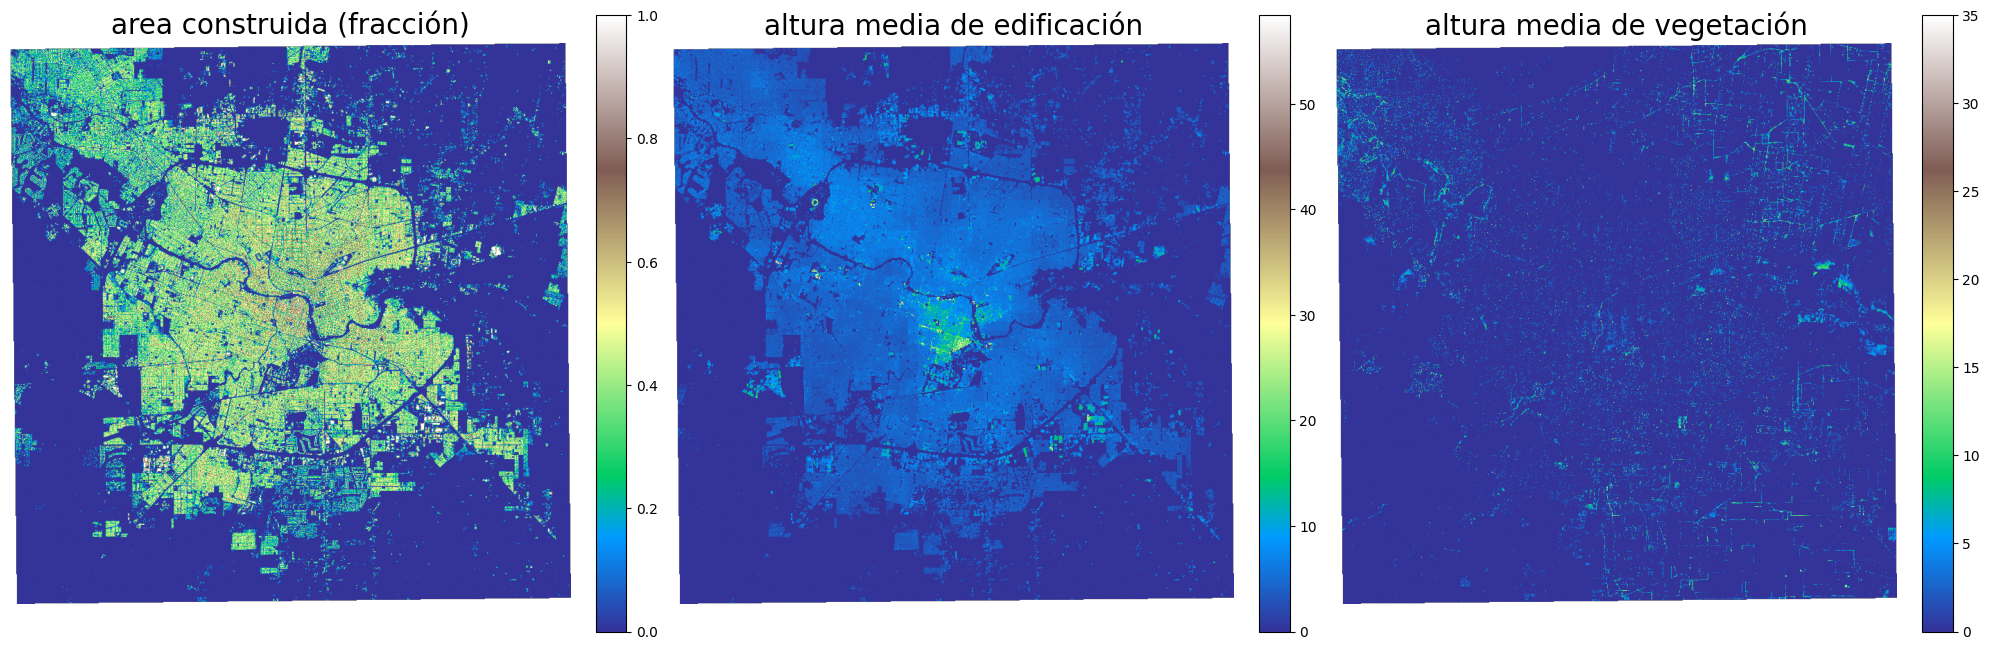

In [12]:
valid_mask = ~np.isnan(lst_clip)

variables = {
    build_footprint_30m: "area construida (fracción)",
    build_height_30m: "altura media de edificación",
    tree_height_30m: "altura media de vegetación",
}

fig, axes = plt.subplots(1, 3, figsize=(20, 20))
axes = axes.flatten()

for ax, (var_name, titulo) in zip(axes, variables.items()):
    with rasterio.open(var_name) as src:
        var_data = src.read(1).astype(float)

    var_data[~valid_mask] = np.nan

    im = ax.imshow(var_data, cmap='terrain')
    ax.set_title(titulo, fontsize=20)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)

plt.tight_layout()
plt.show()

### moving windows

In [13]:
def distance_weighted_kernel(size):
    """Create a distance-weighted Gaussian kernel."""
    assert size % 2 == 1, "Window size must be odd"
    center = size // 2
    y, x = np.ogrid[:size, :size]
    distance = np.sqrt((x - center)**2 + (y - center)**2)
    sigma = size / 4  # controls smoothing strength
    weights = np.exp(-(distance**2) / (2 * sigma**2))
    weights /= weights.sum()  # normalize to sum=1
    return weights


def moving_window_weighted(array, kernel):
    """Apply distance-weighted convolution."""
    return convolve(array, kernel, mode='nearest')

#### Building area

In [ ]:
with rasterio.open(build_footprint_30m) as src:
    data = src.read(1).astype(np.float32)
    profile = src.profile

    # Loop over odd window sizes only
    for window_size in range(1, 101, 2):
        kernel = distance_weighted_kernel(window_size)
        smoothed = moving_window_weighted(data, kernel)

        # Save raster
        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
        out_path = os.path.join(
            mw_building_area, 
            f"building_area_window{window_size}.tif"
        )

        with rasterio.open(out_path, "w", **out_profile) as dst:
            dst.write(smoothed.astype(np.float32), 1)


In [ ]:
# plot

window_sizes = list(range(1, 21, 2))  # odd windows only 

fig, axes = plt.subplots(2, 5, figsize=(20, 8)) 
axes = axes.flatten()

for ax, w in zip(axes, window_sizes):
    raster_path = os.path.join(mw_building_area, f"building_area_window{w}.tif")
    with rasterio.open(raster_path) as src:
        data = src.read(1)  # read first band directly

    im = ax.imshow(data, cmap='viridis')
    ax.set_title(f"Window {w}x{w}")
    ax.axis("off")

fig.suptitle("Building area - Distance-weighted moving window", fontsize=16)
plt.tight_layout()
plt.show()

#### Building volume

In [ ]:
with rasterio.open(build_volume_30m) as src:
    data = src.read(1).astype(np.float32)
    profile = src.profile

    # Loop over odd window sizes only
    for window_size in range(1, 101, 2):
        if window_size == 1:
            smoothed = data.copy()  # window 1 = original
        else:
            kernel = distance_weighted_kernel(window_size)
            smoothed = moving_window_weighted(data, kernel)

        # Save raster
        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
        out_path = os.path.join(
            mw_building_volume, 
            f"buildings_window{window_size}.tif"
        )

        with rasterio.open(out_path, "w", **out_profile) as dst:
            dst.write(smoothed.astype(np.float32), 1)


In [ ]:
window_sizes = list(range(1, 21, 2))  # odd windows only 

fig, axes = plt.subplots(2, 5, figsize=(20, 8))  # 10 windows
axes = axes.flatten()

for ax, w in zip(axes, window_sizes):
    raster_path = os.path.join(mw_building_volume, f"buildings_window{w}.tif")
    with rasterio.open(raster_path) as src:
        data = src.read(1)  # read first band

    im = ax.imshow(data, cmap='viridis')
    ax.set_title(f"Window {w}x{w}")
    ax.axis("off")

fig.suptitle("Building volume - Distance-weighted moving window", fontsize=16)
plt.tight_layout()
plt.show()



#### building height

In [ ]:
with rasterio.open(build_height_30m) as src:
    data = src.read(1).astype(np.float32)
    profile = src.profile

    # Loop over odd window sizes only
    for window_size in range(1, 101, 2):
        if window_size == 1:
            smoothed = data.copy()  # window 1 = original
        else:
            kernel = distance_weighted_kernel(window_size)
            smoothed = moving_window_weighted(data, kernel)

        # Save raster
        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
        out_path = os.path.join(
            mw_building_height, 
            f"building_height_window{window_size}.tif"
        )

        with rasterio.open(out_path, "w", **out_profile) as dst:
            dst.write(smoothed.astype(np.float32), 1)


In [ ]:
# plot

window_sizes = list(range(1, 21, 2))  # odd windows only 

fig, axes = plt.subplots(2, 5, figsize=(20, 8)) 
axes = axes.flatten()

for ax, w in zip(axes, window_sizes):
    raster_path = os.path.join(mw_building_height, f"building_height_window{w}.tif")
    with rasterio.open(raster_path) as src:
        data = src.read(1)  # read first band directly

    im = ax.imshow(data, cmap='viridis')
    ax.set_title(f"Window {w}x{w}")
    ax.axis("off")

fig.suptitle("Building height - Distance-weighted moving window", fontsize=16)
plt.tight_layout()
plt.show()

#### Tree volume

In [ ]:
with rasterio.open(tree_volume_30m) as src:
    data = src.read(1).astype(np.float32)
    profile = src.profile

    for window_size in range(1, 101, 2): # Loop over odd window sizes only
        if window_size == 1:
            smoothed = data.copy()  # window 1 = original
        else:
            kernel = distance_weighted_kernel(window_size)
            smoothed = moving_window_weighted(data, kernel)

        # Save raster
        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
        out_path = os.path.join(
            mw_tree_volume, 
            f"trees_window{window_size}.tif"
        )

        with rasterio.open(out_path, "w", **out_profile) as dst:
            dst.write(smoothed.astype(np.float32), 1)




In [ ]:
window_sizes = list(range(1, 21, 2))  # odd windows only

fig, axes = plt.subplots(2, 5, figsize=(20, 8))  
axes = axes.flatten()

for ax, w in zip(axes, window_sizes):
    raster_path = os.path.join(mw_tree_volume, f"trees_window{w}.tif")
    with rasterio.open(raster_path) as src:
        data = src.read(1)

    im = ax.imshow(data, cmap='YlGn', vmin=0, vmax=10000)
    ax.set_title(f"Window {w}x{w}")
    ax.axis("off")

fig.suptitle("Tree volume - Distance-weighted moving window", fontsize=16)
plt.tight_layout()
plt.show()


#### tree height

In [14]:
with rasterio.open(tree_height_30m) as src:
    data = src.read(1).astype(np.float32)
    profile = src.profile

    for window_size in range(1, 101, 2):  # Loop over odd window sizes only
        if window_size == 1:
            smoothed = data.copy()  # window 1 = original
        else:
            kernel = distance_weighted_kernel(window_size)
            smoothed = moving_window_weighted(data, kernel)

        # Save raster
        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
        out_path = os.path.join(
            mw_tree_height,
            f"trees_height_window{window_size}.tif"
        )

        with rasterio.open(out_path, "w", **out_profile) as dst:
            dst.write(smoothed.astype(np.float32), 1)

In [8]:
# all plots 
valid_mask = ~np.isnan(lst_clip)

variables = {
    build_footprint_30m: "area construida (fracción)",
    build_height_30m: "altura media de edificación",
    tree_height_30m: "altura media de vegetación",
}

fig, axes = plt.subplots(1, 3, figsize=(20, 20))
axes = axes.flatten()

for ax, (var_name, titulo) in zip(axes, variables.items()):
    with rasterio.open(var_name) as src:
        var_data = src.read(1).astype(float)

    var_data[~valid_mask] = np.nan

    im = ax.imshow(var_data, cmap='terrain')
    ax.set_title(titulo, fontsize=20)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)

plt.tight_layout()
plt.show()

NameError: name 'tree_height_30m' is not defined

### Correlations with LST

In [ ]:
# general parameters
window_sizes = list(range(1, 101, 2))  # odd windows only


#### Building area

In [ ]:
correlations = []

for w in window_sizes:
    raster_path = os.path.join(mw_building_area, f"building_area_window{w}.tif")
    with rasterio.open(raster_path) as src:
        raster_data = src.read(1).astype(float)  # read full raster

    # Pixel-by-pixel correlation using only valid LST pixels
    valid_mask = ~np.isnan(lst_clip) 
    var_vals = raster_data[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(var_vals, lst_vals)[0, 1]
    correlations.append(corr)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation building area – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()

#### Building volume

In [ ]:
correlations = []

for w in window_sizes:
    raster_path = os.path.join(mw_building_volume, f"buildings_window{w}.tif")
    with rasterio.open(raster_path) as src:
        raster_data = src.read(1).astype(float)

    valid_mask = ~np.isnan(lst_clip) 
    var_vals = raster_data[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(var_vals, lst_vals)[0, 1]
    correlations.append(corr)

# Plot
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation building volume – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()


#### Tree volume

In [ ]:
correlations = []

for w in window_sizes:
    raster_path = os.path.join(mw_tree_volume, f"trees_window{w}.tif")
    with rasterio.open(raster_path) as src:
        raster_data = src.read(1).astype(float)  

    valid_mask = ~np.isnan(lst_clip) 
    var_vals = raster_data[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(var_vals, lst_vals)[0,1]
    correlations.append(corr)

# Plot
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation tree volume – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()

#### building height

In [ ]:
correlations = []

for w in window_sizes:
    raster_path = os.path.join(mw_building_height, f"building_height_window{w}.tif")
    with rasterio.open(raster_path) as src:
        raster_data = src.read(1).astype(float)  

    valid_mask = ~np.isnan(lst_clip) 
    var_vals = raster_data[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(var_vals, lst_vals)[0,1]
    correlations.append(corr)

# Plot
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation building height – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()


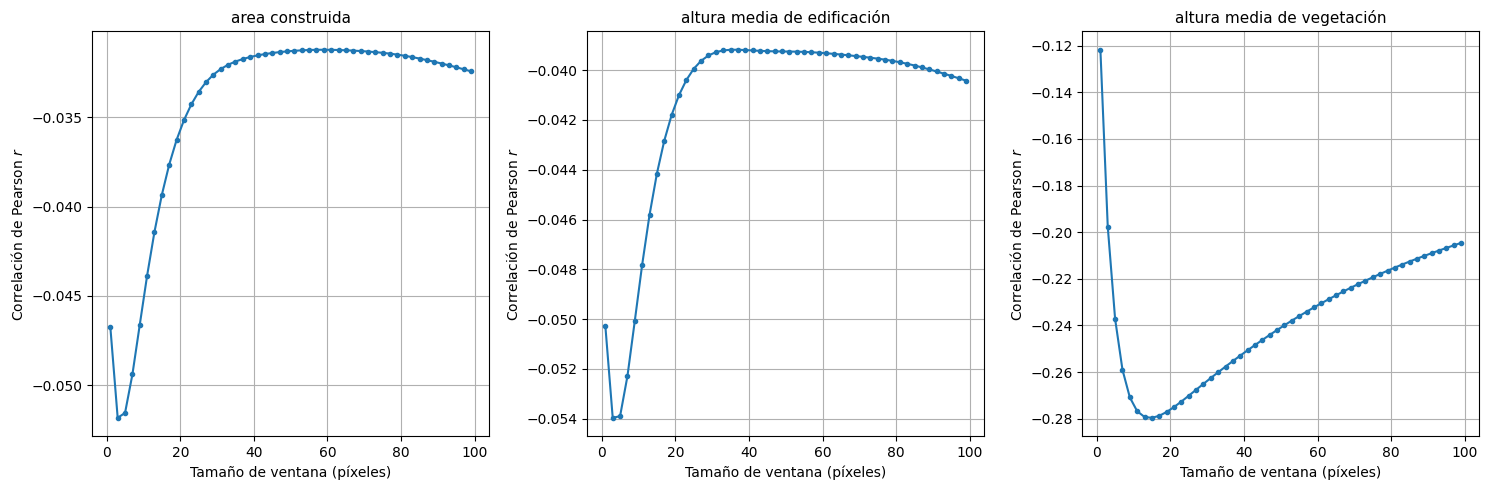

In [15]:
variables = {
    "area construida":             (mw_building_area,  "building_area_window{w}.tif"),
    "altura media de edificación": (mw_building_height, "building_height_window{w}.tif"),
    "altura media de vegetación":  (mw_tree_height,     "trees_height_window{w}.tif"),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for ax, (label, (folder, pattern)) in zip(axes, variables.items()):
    correlations = []

    for w in window_sizes:
        raster_path = os.path.join(folder, pattern.format(w=w))
        with rasterio.open(raster_path) as src_var:
            var_data = src_var.read(1).astype(float)

        valid = ~np.isnan(lst_clip)
        corr = np.corrcoef(var_data[valid], lst_clip[valid])[0, 1]
        correlations.append(corr)

    ax.plot(window_sizes, correlations, marker='o', markersize=3)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Tamaño de ventana (píxeles)")
    ax.set_ylabel("Correlación de Pearson $r$")
    ax.grid(True)


plt.tight_layout()
plt.show()